#Datos generados apartir de ecuación de la velocidad:



In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [3]:
# Generación de Datos (Física del paracaidista)
def fisica_paracaidista(t):
    g, vt, v0, t0 = 9.8, 50.0, 0.0, 0.0
    # Implementación de la fórmula exponencial de la imagen
    numerador = (v0 - vt) * np.exp(g/vt * (t - t0)) + (v0 + vt) * np.exp(-g/vt * (t - t0))
    denominador = (v0 - vt) * np.exp(g/vt * (t - t0)) - (v0 + vt) * np.exp(-g/vt * (t - t0))
    return vt * (numerador / denominador)


In [4]:
# Datos de entrenamiento (puntos enteros: 0, 1, 2...)

t_train = np.linspace(0, 50, 25).reshape(-1, 1)

v_train_clean = fisica_paracaidista(t_train)



# Ruido gaussiano aditivo para simular mediciones experimentales

np.random.seed(42)

noise_std = 0.1 * np.std(v_train_clean)  # 2% de la desviación estándar de la señal

v_train = v_train_clean + np.random.normal(0.0, noise_std, size=v_train_clean.shape)



# Datos de validación (puntos desplazados: 0.5, 1.5...) para ver si hay overfitting

t_test = np.linspace(0, 49.5, 100).reshape(-1, 1)

v_real = fisica_paracaidista(t_test)


# Red Neuronal: 2 capas ocultas, 500 neuronas, activación `tanh`

In [5]:
NUM_CAPAS_OCULTAS = 2
NEURONAS_POR_CAPA = 500
ACTIVACION = 'tanh'
EPOCAS = 1000

model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(1,)))
for _ in range(NUM_CAPAS_OCULTAS):
    model.add(tf.keras.layers.Dense(NEURONAS_POR_CAPA, activation=ACTIVACION))
model.add(tf.keras.layers.Dense(1))
model.compile(optimizer='adam', loss='mse')

print(f"Entrenando red con {NUM_CAPAS_OCULTAS} capas de {NEURONAS_POR_CAPA} neuronas ({ACTIVACION})...")
history = model.fit(t_train, v_train, epochs=EPOCAS, verbose=0)
print("Entrenamiento finalizado.")

v_pred = model.predict(t_test)


Entrenando red con 2 capas de 500 neuronas (tanh)...
Entrenamiento finalizado.
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step


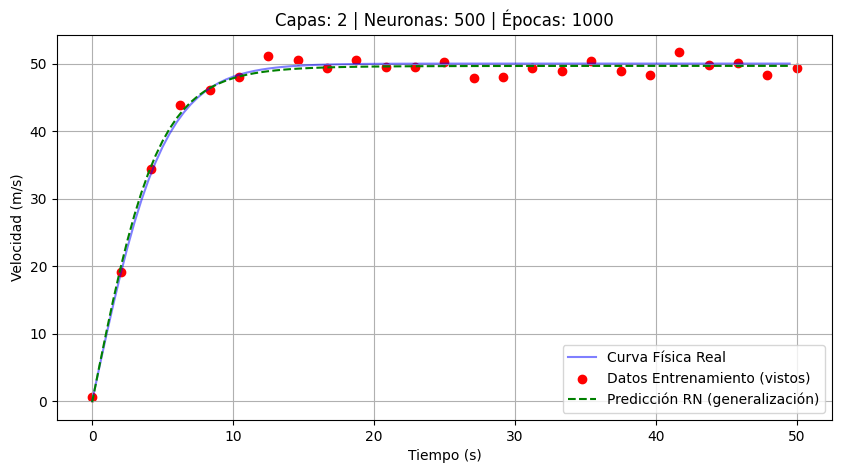

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(t_test, v_real, 'b-', label='Curva Física Real', alpha=0.5)
plt.scatter(t_train, v_train, color='red', label='Datos Entrenamiento (vistos)')
plt.plot(t_test, v_pred, 'g--', label='Predicción RN (generalización)')
plt.title(f'Capas: {NUM_CAPAS_OCULTAS} | Neuronas: {NEURONAS_POR_CAPA} | Épocas: {EPOCAS}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()


# Regresión No-Lineal

La solución analítica exacta del paracaidista (con $v_0=0$) es:

$$v(t) = v_t \tanh\!\left(\frac{g}{v_t}\,t\right)$$

Usamos `scipy.optimize.curve_fit` para ajustar los parámetros $v_t$ y $g$ directamente a los datos de entrenamiento.

In [7]:
from scipy.optimize import curve_fit

# Modelo de regresión: v(t) = vt * tanh(g/vt * t)
def modelo_regresion(t, vt, g):
    return vt * np.tanh(g / vt * t)

# Ajuste con los mismos datos de entrenamiento
t_flat = t_train.flatten()
v_flat = v_train.flatten()

# Valores iniciales cercanos a los físicos reales (vt≈50, g≈9.8)
params_opt, params_cov = curve_fit(modelo_regresion, t_flat, v_flat, p0=[50.0, 9.8])
vt_fit, g_fit = params_opt

print(f"Parámetros ajustados:")
print(f"  v_t (velocidad terminal) = {vt_fit:.4f} m/s  (real: 50.0)")
print(f"  g   (gravedad efectiva)  = {g_fit:.4f} m/s²  (real: 9.8)")

# Predicción de la regresión sobre los datos de test
v_reg = modelo_regresion(t_test.flatten(), vt_fit, g_fit)


Parámetros ajustados:
  v_t (velocidad terminal) = 49.5993 m/s  (real: 50.0)
  g   (gravedad efectiva)  = 10.2605 m/s²  (real: 9.8)


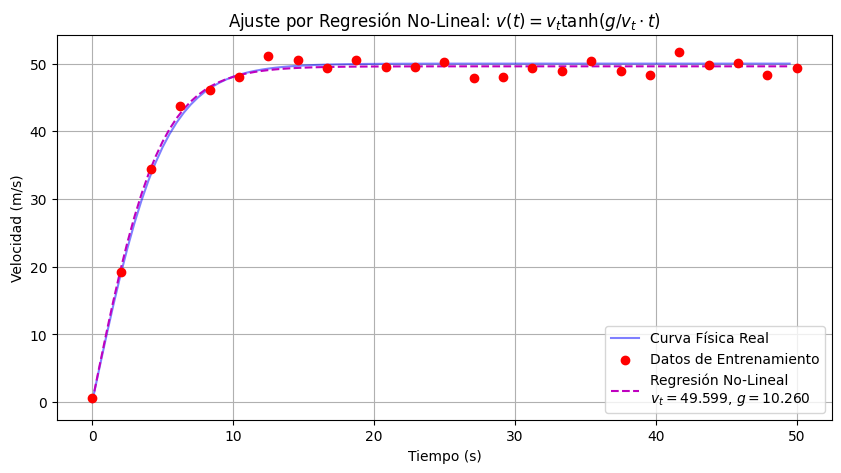

In [8]:
# Gráfica de la regresión
plt.figure(figsize=(10, 5))
plt.plot(t_test, v_real.flatten(), 'b-', label='Curva Física Real', alpha=0.5)
plt.scatter(t_train, v_train, color='red', label='Datos de Entrenamiento', zorder=5)
plt.plot(t_test, v_reg, 'm--', label=f'Regresión No-Lineal\n$v_t={vt_fit:.3f}$, $g={g_fit:.3f}$')
plt.title('Ajuste por Regresión No-Lineal: $v(t) = v_t \\tanh(g/v_t \\cdot t)$')
plt.xlabel('Tiempo (s)')
plt.ylabel('Velocidad (m/s)')
plt.legend()
plt.grid(True)
plt.show()


# Comparación: Red Neuronal vs Regresión No-Lineal

Se compara la red neuronal (2 capas, 500 neuronas, `tanh`, 1000 épocas) con la regresión no-lineal mediante:
- **Gráfica superpuesta** frente a la curva física real
- **MSE** (Error Cuadrático Medio) sobre los datos de test
- **MAE** (Error Absoluto Medio) sobre los datos de test

In [9]:
v_rn_comp  = model.predict(t_test).flatten()
v_real_flat = v_real.flatten()

# Métricas
mse_rn  = np.mean((v_rn_comp  - v_real_flat)**2)
mse_reg = np.mean((v_reg       - v_real_flat)**2)
mae_rn  = np.mean(np.abs(v_rn_comp  - v_real_flat))
mae_reg = np.mean(np.abs(v_reg       - v_real_flat))

print(f"\n{'Método':<35} {'MSE':>12} {'MAE':>12}")
print("-" * 61)
print(f"{'Red Neuronal (2c × 500n, tanh)':<35} {mse_rn:>12.4f} {mae_rn:>12.4f}")
print(f"{'Regresión No-Lineal':<35} {mse_reg:>12.6f} {mae_reg:>12.6f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

Método                                       MSE          MAE
-------------------------------------------------------------
Red Neuronal (2c × 500n, tanh)            0.2032       0.4060
Regresión No-Lineal                     0.190982     0.402301


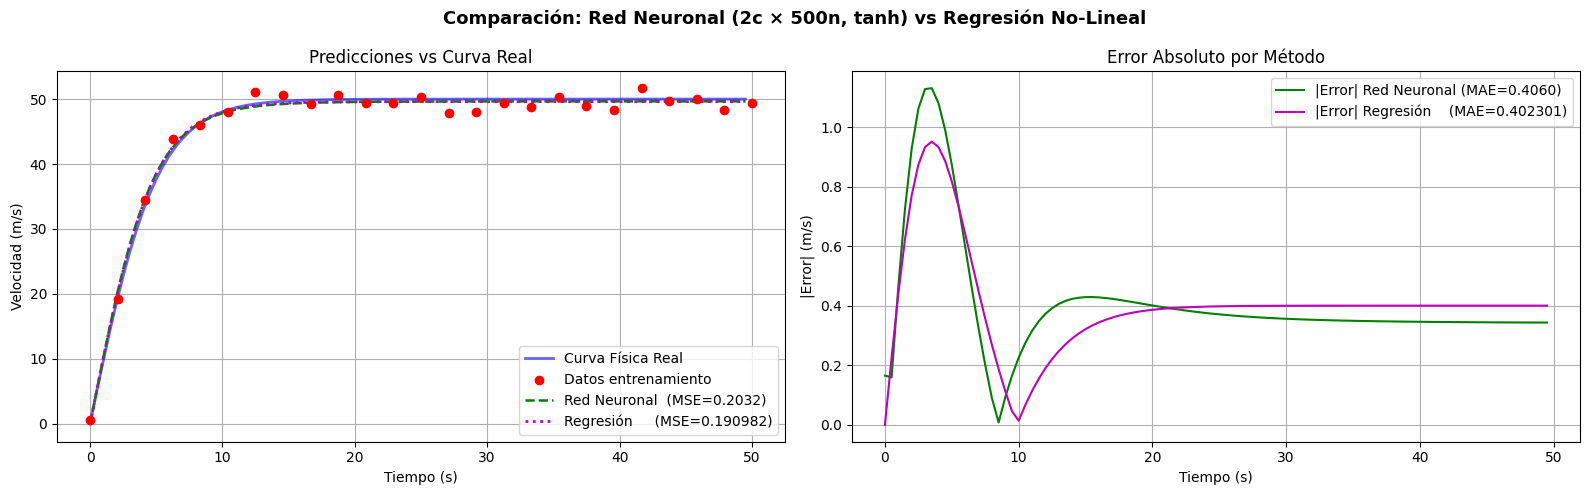

In [10]:
# Gráfica comparativa
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Panel izquierdo: curvas superpuestas ---
ax = axes[0]
ax.plot(t_test, v_real_flat,  'b-',  label='Curva Física Real',        linewidth=2, alpha=0.6)
ax.scatter(t_train, v_train,  color='red', label='Datos entrenamiento',  zorder=5)
ax.plot(t_test, v_rn_comp,   'g--', label=f'Red Neuronal  (MSE={mse_rn:.4f})',  linewidth=1.8)
ax.plot(t_test, v_reg,       'm:',  label=f'Regresión     (MSE={mse_reg:.6f})',  linewidth=2)
ax.set_title('Predicciones vs Curva Real')
ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('Velocidad (m/s)')
ax.legend()
ax.grid(True)

# --- Panel derecho: error absoluto ---
ax2 = axes[1]
ax2.plot(t_test, np.abs(v_rn_comp - v_real_flat), 'g-', label=f'|Error| Red Neuronal (MAE={mae_rn:.4f})')
ax2.plot(t_test, np.abs(v_reg      - v_real_flat), 'm-', label=f'|Error| Regresión    (MAE={mae_reg:.6f})')
ax2.set_title('Error Absoluto por Método')
ax2.set_xlabel('Tiempo (s)')
ax2.set_ylabel('|Error| (m/s)')
ax2.legend()
ax2.grid(True)

plt.suptitle('Comparación: Red Neuronal (2c × 500n, tanh) vs Regresión No-Lineal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# Physics-Informed Neural Network (PINN) con PyTorch

En lugar de ajustar la red únicamente a los datos, incorporaremos la ecuación diferencial subyacente en la función de pérdida. Para un paracaidista con resistencia del aire proporcional al cuadrado de la velocidad, la EDO es:

$$\frac{dv}{dt} = g - \frac{g}{v_t^2} v^2$$

Nuestra función de pérdida total será: $\mathcal{L} = \mathcal{L}_{\text{datos}} + \lambda \mathcal{L}_{\text{física}}$

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim

# Convertir los datos de NumPy a Tensores de PyTorch
# Es crucial activar requires_grad=True en el tiempo para poder calcular la derivada (dv/dt)
t_train_pt = torch.tensor(t_train, dtype=torch.float32, requires_grad=True)
v_train_pt = torch.tensor(v_train, dtype=torch.float32)

t_test_pt = torch.tensor(t_test, dtype=torch.float32, requires_grad=True)
v_real_pt = torch.tensor(v_real, dtype=torch.float32)

# Definir la arquitectura de la PINN
class SkydiverPINN(nn.Module):
    def __init__(self):
        super(SkydiverPINN, self).__init__()
        # Una arquitectura similar: 2 capas ocultas, pero ajustada a PyTorch
        self.net = nn.Sequential(
            nn.Linear(1, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

    def forward(self, t):
        return self.net(t)

# Instanciar el modelo
pinn_model = SkydiverPINN()

In [12]:
# Configuración del entrenamiento PINN

optimizer = optim.Adam(pinn_model.parameters(), lr=0.002)
EPOCAS_PINN = 4000
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCAS_PINN,
    eta_min=2e-4,
)

# Pesos dinámicos: más datos al inicio, más física al final
lambda_data_ini, lambda_data_fin = 0.8, 0.2
lambda_physics_ini, lambda_physics_fin = 5e-2, 1.0
lambda_ic = 10.0  # v(0)=0
lambda_tc = 1.0   # v(50)≈vt

# Constantes físicas
g_fisica = 9.8
vt_fisica = 50.0
v0_fisica = 0.0

# Puntos de colocación física
t_phys_pt = torch.linspace(0.0, 50.0, 300, dtype=torch.float32).reshape(-1, 1)
t_phys_pt.requires_grad_(True)

# Historial para análisis
historial_loss = []
historial_loss_data = []
historial_loss_physics = []
historial_lambda_data = []
historial_lambda_physics = []
historial_wloss_data = []
historial_wloss_physics = []

print("Entrenando la PINN...")

for epoch in range(EPOCAS_PINN):
    pinn_model.train()
    optimizer.zero_grad()
    progreso = epoch / (EPOCAS_PINN - 1)
    lambda_data = lambda_data_ini + (lambda_data_fin - lambda_data_ini) * progreso
    lambda_physics = lambda_physics_ini + (lambda_physics_fin - lambda_physics_ini) * progreso

    # 1) Error de datos

   v_pred_train = pinn_model(t_train_pt)
    loss_data = torch.mean((v_pred_train - v_train_pt) ** 2)

    # 2) Residuo físico
    v_pred_phys = pinn_model(t_phys_pt)
    dv_dt_phys = torch.autograd.grad(
        v_pred_phys,
        t_phys_pt,
        grad_outputs=torch.ones_like(v_pred_phys),
        create_graph=True,
    )[0]

    physics_residual = dv_dt_phys - (g_fisica - (g_fisica / vt_fisica**2) * v_pred_phys**2)
    loss_physics = torch.mean(physics_residual**2)

    # 3) Condiciones de frontera
    t0_pt = torch.zeros((1, 1), dtype=torch.float32)
    tmax_pt = torch.tensor([[50.0]], dtype=torch.float32)
    loss_ic = torch.mean((pinn_model(t0_pt) - v0_fisica) ** 2)
    loss_tc = torch.mean((pinn_model(tmax_pt) - vt_fisica) ** 2)

    # 4) Loss total
    total_loss = (
        lambda_data * loss_data
        + lambda_physics * loss_physics
        + lambda_ic * loss_ic
        + lambda_tc * loss_tc
    )

    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(pinn_model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()

    # Métricas
    historial_loss.append(total_loss.item())
    historial_loss_data.append(loss_data.item())
    historial_loss_physics.append(loss_physics.item())
    historial_lambda_data.append(lambda_data)
    historial_lambda_physics.append(lambda_physics)
    historial_wloss_data.append((lambda_data * loss_data).item())
    historial_wloss_physics.append((lambda_physics * loss_physics).item())

    if (epoch + 1) % 500 == 0:
        print(
            f"Época {epoch+1}/{EPOCAS_PINN} | L_total: {total_loss.item():.6f} "
            f"| L_data: {loss_data.item():.6f} | L_phys: {loss_physics.item():.6f} "
            f"| w_data: {lambda_data:.3f} | w_phys: {lambda_physics:.3f}"
        )


print("Entrenamiento de PINN finalizado.")

pinn_model.eval()

with torch.no_grad():
    v_pinn_pred = pinn_model(t_test_pt).numpy()


Entrenando la PINN...
Época 500/4000 | L_total: 0.994769 | L_data: 0.986645 | L_phys: 0.122338 | w_data: 0.725 | w_phys: 0.169
Época 1000/4000 | L_total: 0.612334 | L_data: 0.702046 | L_phys: 0.097240 | w_data: 0.650 | w_phys: 0.287
Época 1500/4000 | L_total: 0.469698 | L_data: 0.668895 | L_phys: 0.099099 | w_data: 0.575 | w_phys: 0.406
Época 2000/4000 | L_total: 0.397848 | L_data: 0.679733 | L_phys: 0.082296 | w_data: 0.500 | w_phys: 0.525
Época 2500/4000 | L_total: 0.344698 | L_data: 0.692236 | L_phys: 0.068923 | w_data: 0.425 | w_phys: 0.644
Época 3000/4000 | L_total: 0.296495 | L_data: 0.719233 | L_phys: 0.052884 | w_data: 0.350 | w_phys: 0.762
Época 3500/4000 | L_total: 0.242753 | L_data: 0.757361 | L_phys: 0.038196 | w_data: 0.275 | w_phys: 0.881
Época 4000/4000 | L_total: 0.186946 | L_data: 0.806991 | L_phys: 0.025489 | w_data: 0.200 | w_phys: 1.000
Entrenamiento de PINN finalizado.


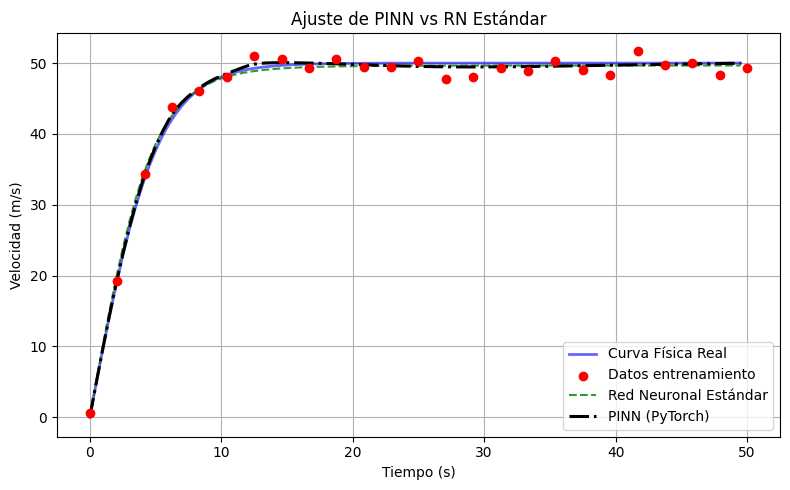

MSE Red Neuronal Estándar: 0.203189
MSE PINN (PyTorch):        0.130240


In [13]:
fig, ax1 = plt.subplots(1, 1, figsize=(8, 5))

# Panel 1: Ajuste de curvas
ax1.plot(t_test, v_real.flatten(), "b-", label="Curva Física Real", linewidth=2, alpha=0.6)
ax1.scatter(t_train, v_train, color="red", label="Datos entrenamiento", zorder=5)
ax1.plot(t_test, v_rn_comp, "g--", label="Red Neuronal Estándar", linewidth=1.5, alpha=0.8)
ax1.plot(t_test, v_pinn_pred, "k-.", label="PINN (PyTorch)", linewidth=2.2)
ax1.set_title("Ajuste de PINN vs RN Estándar")
ax1.set_xlabel("Tiempo (s)")
ax1.set_ylabel("Velocidad (m/s)")
ax1.grid(True)
ax1.legend()

plt.tight_layout()
plt.show()

mse_pinn = np.mean((v_pinn_pred.flatten() - v_real.flatten()) ** 2)
print(f"MSE Red Neuronal Estándar: {mse_rn:.6f}")
print(f"MSE PINN (PyTorch):        {mse_pinn:.6f}")

--- Comparación solo por error ---
La curva Error vs Tiempo usa el tiempo físico t del problema (segundos), no épocas.
RN         | MAE: 0.406039
Regresión  | MAE: 0.402301
PINN       | MAE: 0.313782


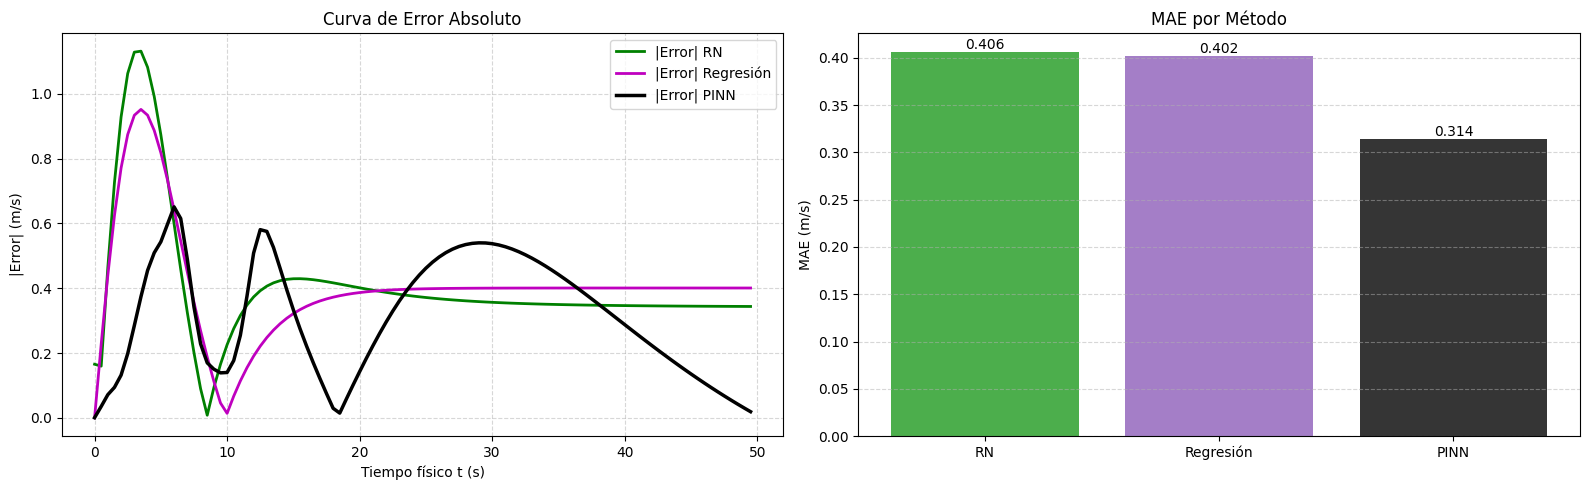

In [14]:
import numpy as np

import matplotlib.pyplot as plt

t_test_flat = t_test.flatten()
v_real_flat = v_real.flatten()

# Error absoluto para cada método en cada instante de tiempo físico t (segundos)
error_rn = np.abs(v_rn_comp - v_real_flat)
error_reg = np.abs(v_reg - v_real_flat)
error_pinn = np.abs(v_pinn_pred.flatten() - v_real_flat)

mae_rn_eval = np.mean(error_rn)
mae_reg_eval = np.mean(error_reg)
mae_pinn_eval = np.mean(error_pinn)

print("--- Comparación solo por error ---")
print("La curva Error vs Tiempo usa el tiempo físico t del problema (segundos), no épocas.")
print(f"RN         | MAE: {mae_rn_eval:.6f}")
print(f"Regresión  | MAE: {mae_reg_eval:.6f}")
print(f"PINN       | MAE: {mae_pinn_eval:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: Curva de error absoluto en función del tiempo físico
ax_err = axes[0]
ax_err.plot(t_test, error_rn, "g-", label="|Error| RN", linewidth=2)
ax_err.plot(t_test, error_reg, "m-", label="|Error| Regresión", linewidth=2)
ax_err.plot(t_test, error_pinn, "k-", label="|Error| PINN", linewidth=2.5)
ax_err.set_title("Curva de Error Absoluto")
ax_err.set_xlabel("Tiempo físico t (s)")
ax_err.set_ylabel("|Error| (m/s)")
ax_err.grid(True, ls="--", alpha=0.5)
ax_err.legend()

# Panel 2: Resumen de MAE por método
ax_mae = axes[1]
metodos = ["RN", "Regresión", "PINN"]
mae_vals = [mae_rn_eval, mae_reg_eval, mae_pinn_eval]
colors = ["#2ca02c", "#9467bd", "#111111"]
bars = ax_mae.bar(metodos, mae_vals, color=colors, alpha=0.85)
ax_mae.set_title("MAE por Método")
ax_mae.set_ylabel("MAE (m/s)")
ax_mae.grid(True, axis="y", ls="--", alpha=0.5)

for bar, val in zip(bars, mae_vals):
    ax_mae.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()